In [6]:
#load dataset
df = pd.read_csv('car data.csv')

In [25]:

# STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error



In [7]:

# STEP 3: Display First 5 Rows

print("FIRST 5 ROWS OF DATASET:")
print(df.head())



FIRST 5 ROWS OF DATASET:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [8]:

# STEP 4: Check Dataset Information

print("\nDATASET INFORMATION:")
print(df.info())




DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [9]:

# STEP 5: Check Missing Values

print("\nMISSING VALUES:")
print(df.isnull().sum())




MISSING VALUES:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [16]:
from sklearn.preprocessing import LabelEncoder
#Step 6 - Convert Categorical Data into Numerical Data
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df['Car_Name'] = le.fit_transform(df['Car_Name'])

In [18]:
# Step 7 - Define Features and Target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']


In [20]:
# Step 8 - Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Step 9 - Train the Model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [22]:

# Step 10 - Predict Car Prices
y_pred = model.predict(X_test)


In [26]:
# Step 11 - Evaluate Model Performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)



Model Evaluation
Mean Absolute Error: 1.2147329896540084
Mean Squared Error: 3.537020423742584
R2 Score: 0.8464540623821766


In [27]:


# Step 12 - Compare Actual vs Predicted Values
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print("\nActual vs Predicted Prices:")
print(comparison.head())




Actual vs Predicted Prices:
     Actual Price  Predicted Price
177          0.35         2.974919
289         10.11         8.326128
228          4.95         6.016123
198          0.15        -1.381724
60           6.95         9.279406


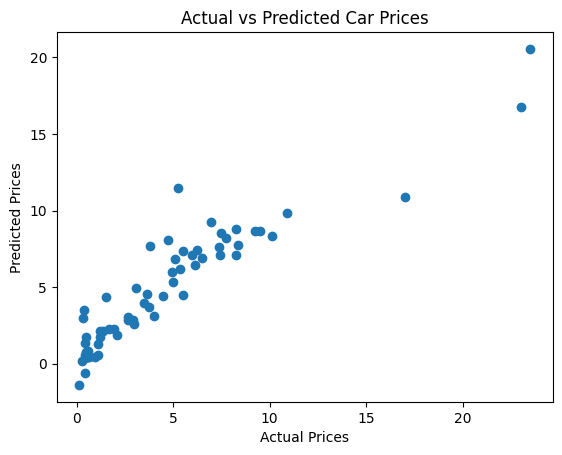

In [28]:
# TASK 3: Car Price Prediction with Machine Learning
# Step 13 - Plot Graph
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()